# EEG α波和β波时间变化分析

## 项目说明

本 Notebook 用于**观察和对比音乐干预前后 α 波和 β 波的变化**。

### 背景知识
- **α波 (8-13 Hz)**：与放松、平静状态相关。α波能量增强通常表示被试进入更放松的状态。
- **β波 (13-30 Hz)**：与警觉、专注、紧张状态相关。β波能量降低可能表示压力减轻。
- **α/β 比率**：α波与β波能量的比值，比值越高通常意味着越放松。

### 分析流程
1. **数据加载**：读取 16 通道 EEG 原始数据（CSV 格式）
2. **预处理**：带通滤波（0.5-40 Hz）+ Z-score 标准化
3. **频段能量计算**：使用滑动窗口 + Welch 方法计算 α/β 波段能量
4. **可视化对比**：绘制干预前后的波形变化对比图

## 1. 导入依赖库与全局配置

In [22]:
# ============================================================
# 导入所需的Python库
# ============================================================
import numpy as np          # 数值计算库，用于数组操作和数学运算
import pandas as pd         # 数据处理库，用于读取CSV文件
import matplotlib.pyplot as plt  # 绘图库，用于生成可视化图表
from scipy import signal    # 信号处理库，用于滤波和频谱分析
import os                   # 操作系统接口，用于文件路径操作

# ============================================================
# Matplotlib 全局配置
# ============================================================
# 使用支持中文的字体（仅用于非图表的输出，图表内文字将使用英文）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
# 解决负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

# 设置 Jupyter Notebook 内联显示图表
%matplotlib inline

print("✓ 所有依赖库导入成功！")

✓ 所有依赖库导入成功！


In [23]:
# ============================================================
# 分析参数配置
# ============================================================

# 采样率 (Hz) -- EEG设备的数据采集频率
# 本项目使用的脑电采集设备采样率为 202 Hz
SAMPLING_RATE = 202

# 滑动窗口大小(单位:秒)
# 用于计算频段能量的时间窗口长度
# 较大的值(如5秒)会使曲线更平滑,适合观察整体趋势
# 较小的值(如2秒)会捕捉更多细节变化
WINDOW_SIZE = 4

# 窗口重叠比例 (范围: 0-1)
# 相邻窗口之间重叠的比例,越大生成的数据点越密集、曲线越平滑
# 0.75 表示相邻窗口重叠 75%
OVERLAP = 0.75

# 要分析的通道设置
# - 'all'    : 使用所有16个通道的平均值(推荐,可以减少单通道噪声影响)
# - 整数(0-15): 分析单个通道,如 0 表示 CH0
# - 列表      : 多个通道的平均,如 [0, 1, 2] 表示 CH0/CH1/CH2 的平均
CHANNELS = 'all'

# ============================================================
# 数据文件路径配置
# ============================================================

# 干预前的 EEG 数据文件路径(Alert 状态下的脑电数据)
FILE_BEFORE = "./dataset/train/Alert/CurveData_3_Shakespere_English_Test.csv"

# 干预后的 EEG 数据文件路径(Relaxed 状态下的脑电数据)
FILE_AFTER = "./dataset/train/Relaxed/CurveData_1_Conversation.csv"

print(f"\nConfiguration:")
print(f"  Sampling Rate: {SAMPLING_RATE} Hz")
print(f"  Window Size: {WINDOW_SIZE} s")
print(f"  Overlap: {OVERLAP*100:.0f}%")
print(f"  Channels: {CHANNELS}")


Configuration:
  Sampling Rate: 202 Hz
  Window Size: 4 s
  Overlap: 75%
  Channels: all


## 3. 定义数据加载与预处理函数

包含两个核心函数:
- `load_eeg_data()`: 从CSV文件加载16通道EEG原始数据
- `preprocess_eeg()`: 对原始数据进行带通滤波和Z-score标准化

In [24]:
def load_eeg_data(csv_file):
    """
    加载EEG数据(16通道)
    
    CSV文件格式说明:
    - 第1列: 时间戳(跳过)
    - 第2-17列: CH0 ~ CH15 共16个脑电通道数据
    
    参数:
        csv_file: str, CSV文件路径
    
    返回:
        eeg_data: numpy数组, 形状为 (时间点数, 16通道)
    """
    # 检查文件是否存在
    if not os.path.exists(csv_file):
        raise FileNotFoundError(f"File not found: {csv_file}")
    
    # 读取CSV文件
    # skiprows=1: 跳过第一行的标题行
    # usecols=range(1,17): 只读取第2~17列(即CH0~CH15共16个通道)
    df = pd.read_csv(csv_file, skiprows=1, usecols=range(1, 17))
    
    # 将DataFrame转换为numpy数组, 方便后续数值计算
    eeg_data = df.values
    
    print(f"  Data loaded: {os.path.basename(csv_file)}")
    print(f"  Shape: {eeg_data.shape} (samples={eeg_data.shape[0]}, channels={eeg_data.shape[1]})")
    print(f"  Duration: {eeg_data.shape[0]/SAMPLING_RATE:.1f} seconds")
    
    return eeg_data


def preprocess_eeg(eeg_data, sampling_rate=202, lowcut=0.5, highcut=40):
    """
    预处理EEG数据: 带通滤波 + Z-score标准化
    
    处理步骤:
    1. 带通滤波(0.5-40 Hz): 去除直流偏移和高频噪声
       - 低频截止 0.5 Hz: 去除基线漂移
       - 高频截止 40 Hz: 去除工频干扰(50Hz)和肌电伪迹
    2. Z-score标准化: 使每个通道的数据均值为0、标准差为1
       - 消除不同通道之间的幅值差异
    
    参数:
        eeg_data: numpy数组, 原始EEG数据, 形状 (时间点数, 通道数)
        sampling_rate: int, 采样率(Hz)
        lowcut: float, 带通滤波低频截止频率(Hz)
        highcut: float, 带通滤波高频截止频率(Hz)
    
    返回:
        filtered_data: numpy数组, 预处理后的EEG数据
    """
    # ---- 第1步: 带通滤波 ----
    # 计算Nyquist频率(采样率的一半), 用于归一化截止频率
    nyquist = sampling_rate / 2.0
    
    # 将截止频率归一化到 [0, 1] 范围(相对于Nyquist频率)
    low = lowcut / nyquist    # 低频截止的归一化值
    high = highcut / nyquist  # 高频截止的归一化值
    
    # 设计4阶Butterworth带通滤波器
    # 4阶滤波器在截止频率处有较陡的衰减特性
    b, a = signal.butter(4, [low, high], btype='band')
    
    # 使用零相位滤波(filtfilt), 避免引入相位延迟
    # axis=0 表示沿时间轴进行滤波(每个通道独立滤波)
    filtered_data = signal.filtfilt(b, a, eeg_data, axis=0)
    
    # ---- 第2步: Z-score标准化 ----
    # 计算每个通道的均值和标准差
    mean = np.mean(filtered_data, axis=0, keepdims=True)  # 形状: (1, 通道数)
    std = np.std(filtered_data, axis=0, keepdims=True)    # 形状: (1, 通道数)
    
    # 标准化: (x - mean) / std
    filtered_data = (filtered_data - mean) / (std )
    
    return filtered_data

print("Functions defined: load_eeg_data(), preprocess_eeg()")

Functions defined: load_eeg_data(), preprocess_eeg()


## 4. 定义频段能量时间序列计算函数

使用**滑动窗口 + Welch功率谱估计**方法，计算指定频段(如alpha波8-13Hz、beta波13-30Hz)的能量随时间的变化。

**原理说明**:
- 将整段EEG数据按照固定窗口大小(如4秒)进行分段
- 对每个窗口内的数据使用 Welch 方法计算功率谱密度(PSD)
- 提取目标频段范围内的平均功率作为该时刻的频段能量
- 相邻窗口之间有一定重叠，以提高时间分辨率

In [25]:
def calculate_band_power_timeseries(eeg_data, sampling_rate=202, 
                                    band_range=(8, 13), 
                                    window_size=4, 
                                    overlap=0.5,
                                    channels='all'):
    """
    计算指定频段能量随时间的变化(时间序列)
    
    使用滑动窗口方法, 对每个窗口计算Welch功率谱密度(PSD),
    然后提取目标频段的平均能量, 得到该频段能量随时间变化的曲线。
    
    参数:
        eeg_data: numpy数组, 预处理后的EEG数据, 形状 (时间点数, 通道数)
        sampling_rate: int, 采样率(Hz)
        band_range: tuple, 频段范围(Hz), 例如:
                    - (8, 13) 表示 alpha 波
                    - (13, 30) 表示 beta 波
                    - (4, 8) 表示 theta 波
                    - (0.5, 4) 表示 delta 波
        window_size: float, 滑动窗口大小(秒)
        overlap: float, 窗口重叠比例(0-1之间)
        channels: 要分析的通道
                 - 'all': 所有16个通道的平均
                 - 整数: 单个通道索引 (0-15)
                 - 列表: 多个通道索引的平均, 如 [0, 1, 2]
    
    返回:
        time_points: numpy数组, 每个窗口中心对应的时间点(秒)
        power_timeseries: numpy数组, 对应时间点的频段能量值
    """
    # ---- 通道选择 ----
    if channels == 'all':
        # 所有通道取平均, 将多通道数据压缩为单通道
        data_to_analyze = np.mean(eeg_data, axis=1)
    elif isinstance(channels, int):
        # 选择单个通道
        data_to_analyze = eeg_data[:, channels]
    elif isinstance(channels, list):
        # 选择多个通道并取平均
        data_to_analyze = np.mean(eeg_data[:, channels], axis=1)
    else:
        raise ValueError("channels must be 'all', int, or list")
    
    # ---- 计算窗口参数 ----
    # 将窗口大小从秒转换为采样点数
    window_samples = int(window_size * sampling_rate)
    # 计算窗口滑动步长(采样点数)
    # 例如: 窗口808点, 重叠75%, 步长 = 808 * 0.25 = 202点
    step_samples = int(window_samples * (1 - overlap))
    
    # ---- 滑动窗口遍历计算 ----
    time_points = []       # 存储每个窗口中心时刻
    power_timeseries = []  # 存储每个窗口的频段能量
    
    # 从数据起始位置开始, 每次滑动 step_samples 个点
    for start in range(0, len(data_to_analyze) - window_samples, step_samples):
        end = start + window_samples
        # 提取当前窗口内的数据
        window_data = data_to_analyze[start:end]
        
        # 使用 Welch 方法计算该窗口的功率谱密度(PSD)
        # nperseg: 每个FFT段的长度, 取 min(256, 窗口长度)
        # 返回: freqs(频率轴), power(对应的功率谱密度)
        freqs, power = signal.welch(
            window_data, 
            fs=sampling_rate, 
            nperseg=min(256, window_samples)
        )
        
        # 提取目标频段范围内的频率索引
        idx_band = np.logical_and(freqs >= band_range[0], freqs <= band_range[1])
        
        # 计算目标频段的平均功率(即该频段的能量)
        band_power = np.mean(power[idx_band])
        
        # 记录该窗口中心时刻(秒) 和 频段能量
        time_point = (start + end) / 2 / sampling_rate
        time_points.append(time_point)
        power_timeseries.append(band_power)
    
    return np.array(time_points), np.array(power_timeseries)

print("Function defined: calculate_band_power_timeseries()")

Function defined: calculate_band_power_timeseries()


## 5. 定义单文件 Alpha/Beta 波形变化绘图函数

对单个EEG数据文件进行分析，绘制alpha波和beta波能量随时间变化的图表。

图表内容包含:
- Alpha波(8-13 Hz)能量随时间变化曲线
- Beta波(13-30 Hz)能量随时间变化曲线
- 各波段的均值参考线和标准差区间

In [26]:
def plot_alpha_beta_changes(csv_file, 
                            sampling_rate=202,
                            window_size=4,
                            overlap=0.75,
                            channels='all',
                            output_file=None):
    """
    绘制单个文件的 alpha 波和 beta 波随时间变化的图表
    
    完整分析流程: 加载数据 -> 预处理 -> 计算频段能量 -> 绘制图表
    图表中所有标注文字均为英文
    
    参数:
        csv_file: str, EEG数据文件路径
        sampling_rate: int, 采样率(Hz)
        window_size: float, 滑动窗口大小(秒)
        overlap: float, 窗口重叠比例(0-1)
        channels: 要分析的通道('all'、整数或列表)
        output_file: str或None, 输出图片文件路径(可选, 不指定则不保存)
    
    返回:
        fig: matplotlib Figure对象
        (time_alpha, power_alpha): alpha波的时间和能量数组
        (time_beta, power_beta): beta波的时间和能量数组
    """
    print(f"\n{'='*60}")
    print(f"Analyzing: {os.path.basename(csv_file)}")
    print(f"{'='*60}")
    
    # ---- 第1步: 加载原始EEG数据 ----
    eeg_data = load_eeg_data(csv_file)
    
    # ---- 第2步: 预处理(滤波 + 标准化) ----
    print("  Preprocessing (bandpass filter + z-score)...")
    filtered_data = preprocess_eeg(eeg_data, sampling_rate)
    
    # ---- 第3步: 计算 alpha 波能量时间序列 ----
    print("  Computing Alpha band (8-13 Hz) power...")
    time_alpha, power_alpha = calculate_band_power_timeseries(
        filtered_data, 
        sampling_rate=sampling_rate,
        band_range=(8, 13),  # alpha波频段: 8-13 Hz
        window_size=window_size,
        overlap=overlap,
        channels=channels
    )
    
    # ---- 第4步: 计算 beta 波能量时间序列 ----
    print("  Computing Beta band (13-30 Hz) power...")
    time_beta, power_beta = calculate_band_power_timeseries(
        filtered_data, 
        sampling_rate=sampling_rate,
        band_range=(13, 30),  # beta波频段: 13-30 Hz
        window_size=window_size,
        overlap=overlap,
        channels=channels
    )
    
    # ---- 第5步: 绘制图表(所有文字用英文) ----
    print("  Plotting...")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # --- Alpha 波子图 ---
    ax1.plot(time_alpha, power_alpha, 'g-', linewidth=2, label='Alpha (8-13 Hz)')
    ax1.fill_between(time_alpha, power_alpha, alpha=0.3, color='green')
    ax1.set_ylabel('Alpha Power', fontsize=12, fontweight='bold')
    ax1.set_title('Alpha Band Power Over Time', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # 添加统计参考线: 均值虚线 + 标准差区间
    alpha_mean = np.mean(power_alpha)
    alpha_std = np.std(power_alpha)
    ax1.axhline(y=alpha_mean, color='darkgreen', linestyle='--', linewidth=1.5, 
                alpha=0.7, label=f'Mean={alpha_mean:.4f}')
    ax1.fill_between(time_alpha, alpha_mean - alpha_std, alpha_mean + alpha_std, 
                     color='green', alpha=0.1, label=f'+/-1 Std Dev')
    ax1.legend(loc='upper right', fontsize=9)
    
    # --- Beta 波子图 ---
    ax2.plot(time_beta, power_beta, 'orange', linewidth=2, label='Beta (13-30 Hz)')
    ax2.fill_between(time_beta, power_beta, alpha=0.3, color='orange')
    ax2.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Beta Power', fontsize=12, fontweight='bold')
    ax2.set_title('Beta Band Power Over Time', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 添加统计参考线: 均值虚线 + 标准差区间
    beta_mean = np.mean(power_beta)
    beta_std = np.std(power_beta)
    ax2.axhline(y=beta_mean, color='darkorange', linestyle='--', linewidth=1.5, 
                alpha=0.7, label=f'Mean={beta_mean:.4f}')
    ax2.fill_between(time_beta, beta_mean - beta_std, beta_mean + beta_std, 
                     color='orange', alpha=0.1, label=f'+/-1 Std Dev')
    ax2.legend(loc='upper right', fontsize=9)
    
    # --- 通道信息(用于标题显示) ---
    if channels == 'all':
        channel_info = "Average of all 16 channels"
    elif isinstance(channels, int):
        channel_info = f"Channel CH{channels}"
    else:
        channel_info = f"Average of channels {channels}"
    
    # 设置总标题
    plt.suptitle(
        f'EEG Alpha & Beta Band Power Analysis\n'
        f'File: {os.path.basename(csv_file)} | {channel_info}', 
        fontsize=14, fontweight='bold', y=0.995
    )
    
    plt.tight_layout()
    
    # 保存图片(如果指定了输出路径)
    if output_file:
        plt.savefig(output_file, dpi=150, bbox_inches='tight')
        print(f"  Figure saved: {output_file}")
    
    # 在Notebook中内联显示图表
    plt.show()
    
    # ---- 打印统计摘要 ----
    print(f"\n{'='*60}")
    print("Statistics Summary:")
    print(f"{'='*60}")
    print(f"Alpha Band (8-13 Hz):")
    print(f"  Mean:  {alpha_mean:.6f}")
    print(f"  Std:   {alpha_std:.6f}")
    print(f"  Max:   {np.max(power_alpha):.6f} (at {time_alpha[np.argmax(power_alpha)]:.2f}s)")
    print(f"  Min:   {np.min(power_alpha):.6f} (at {time_alpha[np.argmin(power_alpha)]:.2f}s)")
    print(f"\nBeta Band (13-30 Hz):")
    print(f"  Mean:  {beta_mean:.6f}")
    print(f"  Std:   {beta_std:.6f}")
    print(f"  Max:   {np.max(power_beta):.6f} (at {time_beta[np.argmax(power_beta)]:.2f}s)")
    print(f"  Min:   {np.min(power_beta):.6f} (at {time_beta[np.argmin(power_beta)]:.2f}s)")
    print(f"\nAlpha/Beta Ratio: {alpha_mean/beta_mean:.4f}")
    print(f"{'='*60}")
    
    return fig, (time_alpha, power_alpha), (time_beta, power_beta)

print("Function defined: plot_alpha_beta_changes()")

Function defined: plot_alpha_beta_changes()


## 6. 执行分析: 单文件 Alpha/Beta 波形变化

先对干预前的单个文件进行分析,观察alpha波和beta波的时间变化趋势。


Analyzing: CurveData_3_Shakespere_English_Test.csv
  Data loaded: CurveData_3_Shakespere_English_Test.csv
  Shape: (65852, 16) (samples=65852, channels=16)
  Duration: 326.0 seconds
  Preprocessing (bandpass filter + z-score)...
  Computing Alpha band (8-13 Hz) power...
  Computing Beta band (13-30 Hz) power...
  Plotting...


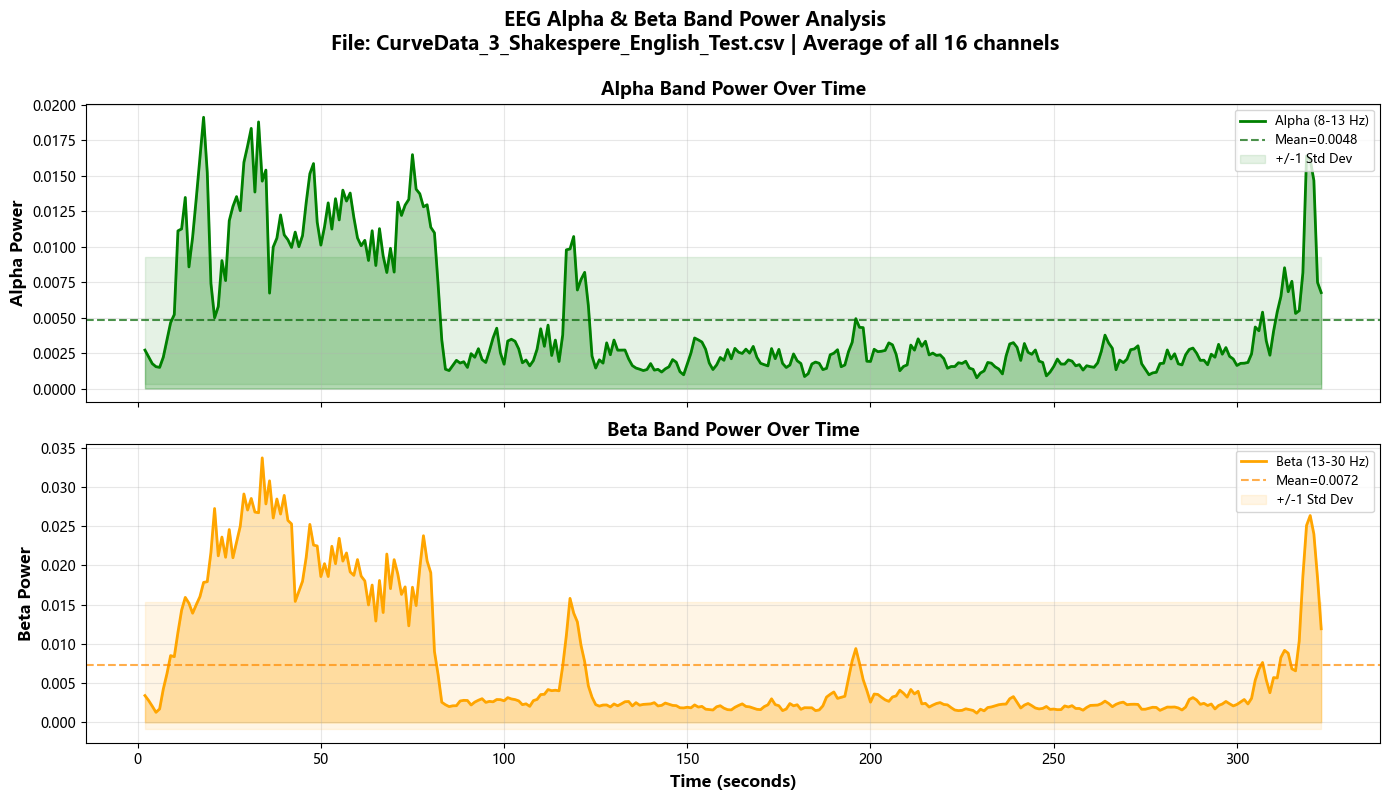


Statistics Summary:
Alpha Band (8-13 Hz):
  Mean:  0.004831
  Std:   0.004476
  Max:   0.019137 (at 18.00s)
  Min:   0.000760 (at 229.00s)

Beta Band (13-30 Hz):
  Mean:  0.007245
  Std:   0.008116
  Max:   0.033693 (at 34.00s)
  Min:   0.001165 (at 229.00s)

Alpha/Beta Ratio: 0.6668


In [27]:
# ============================================================
# 单文件分析: 对干预前的EEG数据进行 alpha/beta 波形变化分析
# ============================================================

# 调用 plot_alpha_beta_changes 函数
# 该函数会自动完成: 加载数据 -> 预处理 -> 计算频段能量 -> 绘图
# 图表将直接在单元格输出中显示
fig_single, alpha_data, beta_data = plot_alpha_beta_changes(
    csv_file=FILE_BEFORE,          # 要分析的EEG数据文件
    sampling_rate=SAMPLING_RATE,    # 采样率
    window_size=WINDOW_SIZE,        # 滑动窗口大小
    overlap=OVERLAP,                # 窗口重叠比例
    channels=CHANNELS               # 分析通道
)

## 7. 定义音乐干预前后对比分析函数

**核心功能**: 同时加载干预前和干预后的EEG数据，计算各自的alpha波和beta波能量，并在同一张图中进行直观对比。

图表布局(2x2):
| | 左列(干预前 / Pre-Intervention) | 右列(干预后 / Post-Intervention) |
|---|---|---|
| **上行** | Alpha波 - 干预前 | Alpha波 - 干预后 |
| **下行** | Beta波 - 干预前 | Beta波 - 干预后 |

同时输出统计对比结果，包括各波段能量的变化百分比和结论。

In [28]:
def compare_before_after(file_before, file_after,
                        sampling_rate=202,
                        window_size=4,
                        overlap=0.75,
                        channels='all',
                        output_file=None):
    """
    对比音乐干预前后的 alpha 波和 beta 波变化
    
    分别对干预前和干预后的数据进行频段能量计算,
    然后在2x2的子图中进行对比展示。
    图表中所有文字均使用英文。
    
    参数:
        file_before: str, 干预前的EEG数据文件路径
        file_after: str, 干预后的EEG数据文件路径
        sampling_rate: int, 采样率(Hz)
        window_size: float, 窗口大小(秒)
        overlap: float, 重叠比例(0-1)
        channels: 分析的通道('all'、整数或列表)
        output_file: str或None, 输出图片路径(可选)
    
    返回:
        fig: matplotlib Figure 对象
    """

    print("# Pre/Post Music Intervention Comparison")
    
    # ============================================================
    # 第1部分: 分析干预前数据
    # ============================================================
    print("[1/2] Processing PRE-intervention data...")
    eeg_before = load_eeg_data(file_before)
    filtered_before = preprocess_eeg(eeg_before, sampling_rate)
    
    # 计算干预前的 alpha 波能量时间序列
    time_alpha_before, power_alpha_before = calculate_band_power_timeseries(
        filtered_before, sampling_rate, (8, 13), window_size, overlap, channels)
    # 计算干预前的 beta 波能量时间序列
    time_beta_before, power_beta_before = calculate_band_power_timeseries(
        filtered_before, sampling_rate, (13, 30), window_size, overlap, channels)
    
    # ============================================================
    # 第2部分: 分析干预后数据
    # ============================================================
    print("\n[2/2] Processing POST-intervention data...")
    eeg_after = load_eeg_data(file_after)
    filtered_after = preprocess_eeg(eeg_after, sampling_rate)
    
    # 计算干预后的 alpha 波能量时间序列
    time_alpha_after, power_alpha_after = calculate_band_power_timeseries(
        filtered_after, sampling_rate, (8, 13), window_size, overlap, channels)
    # 计算干预后的 beta 波能量时间序列
    time_beta_after, power_beta_after = calculate_band_power_timeseries(
        filtered_after, sampling_rate, (13, 30), window_size, overlap, channels)
    
    # ============================================================
    # 第3部分: 绘制2x2对比图(所有文字用英文)
    # ============================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    
    # ---- 左上: Alpha波 - 干预前 ----
    axes[0, 0].plot(time_alpha_before, power_alpha_before, 'b-', 
                    linewidth=2, label='Pre-Intervention', alpha=0.7)
    axes[0, 0].fill_between(time_alpha_before, power_alpha_before, alpha=0.2, color='blue')
    axes[0, 0].set_ylabel('Alpha Power', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Alpha Band - Pre-Intervention', fontsize=12, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    # 添加均值参考线
    axes[0, 0].axhline(y=np.mean(power_alpha_before), color='darkblue', 
                       linestyle='--', linewidth=1.5, alpha=0.7,
                       label=f'Mean={np.mean(power_alpha_before):.4f}')
    axes[0, 0].legend(loc='upper right', fontsize=8)
    
    # ---- 右上: Alpha波 - 干预后 ----
    axes[0, 1].plot(time_alpha_after, power_alpha_after, 'g-', 
                    linewidth=2, label='Post-Intervention', alpha=0.7)
    axes[0, 1].fill_between(time_alpha_after, power_alpha_after, alpha=0.2, color='green')
    axes[0, 1].set_ylabel('Alpha Power', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Alpha Band - Post-Intervention', fontsize=12, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=np.mean(power_alpha_after), color='darkgreen', 
                       linestyle='--', linewidth=1.5, alpha=0.7,
                       label=f'Mean={np.mean(power_alpha_after):.4f}')
    axes[0, 1].legend(loc='upper right', fontsize=8)
    
    # ---- 左下: Beta波 - 干预前 ----
    axes[1, 0].plot(time_beta_before, power_beta_before, 'r-', 
                    linewidth=2, label='Pre-Intervention', alpha=0.7)
    axes[1, 0].fill_between(time_beta_before, power_beta_before, alpha=0.2, color='red')
    axes[1, 0].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('Beta Power', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Beta Band - Pre-Intervention', fontsize=12, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=np.mean(power_beta_before), color='darkred', 
                       linestyle='--', linewidth=1.5, alpha=0.7,
                       label=f'Mean={np.mean(power_beta_before):.4f}')
    axes[1, 0].legend(loc='upper right', fontsize=8)
    
    # ---- 右下: Beta波 - 干预后 ----
    axes[1, 1].plot(time_beta_after, power_beta_after, 'orange', 
                    linewidth=2, label='Post-Intervention', alpha=0.7)
    axes[1, 1].fill_between(time_beta_after, power_beta_after, alpha=0.2, color='orange')
    axes[1, 1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Beta Power', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Beta Band - Post-Intervention', fontsize=12, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axhline(y=np.mean(power_beta_after), color='darkorange', 
                       linestyle='--', linewidth=1.5, alpha=0.7,
                       label=f'Mean={np.mean(power_beta_after):.4f}')
    axes[1, 1].legend(loc='upper right', fontsize=8)
    
    # 设置总标题
    plt.suptitle('Alpha & Beta Band Power: Pre vs. Post Music Intervention', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # 保存图片
    if output_file:
        plt.savefig(output_file, dpi=150, bbox_inches='tight')
        print(f"\nFigure saved: {output_file}")
    
    # 显示图1
    plt.show()
    
    # ============================================================
    # 第4部分: 绘制叠加对比图(干预前后在同一子图中对比)
    # ============================================================
    fig2, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(14, 8))
    
    # --- Alpha 波叠加对比 ---
    ax_a.plot(time_alpha_before, power_alpha_before, 'b-', linewidth=2, 
              label='Pre-Intervention', alpha=0.7)
    ax_a.plot(time_alpha_after, power_alpha_after, 'g-', linewidth=2, 
              label='Post-Intervention', alpha=0.7)
    ax_a.axhline(y=np.mean(power_alpha_before), color='blue', linestyle='--', 
                 linewidth=1, alpha=0.5, label=f'Pre Mean={np.mean(power_alpha_before):.4f}')
    ax_a.axhline(y=np.mean(power_alpha_after), color='green', linestyle='--', 
                 linewidth=1, alpha=0.5, label=f'Post Mean={np.mean(power_alpha_after):.4f}')
    ax_a.set_ylabel('Alpha Power', fontsize=12, fontweight='bold')
    ax_a.set_title('Alpha Band (8-13 Hz): Pre vs. Post Intervention', fontsize=13, fontweight='bold')
    ax_a.legend(loc='upper right', fontsize=9)
    ax_a.grid(True, alpha=0.3)
    
    # --- Beta 波叠加对比 ---
    ax_b.plot(time_beta_before, power_beta_before, 'r-', linewidth=2, 
              label='Pre-Intervention', alpha=0.7)
    ax_b.plot(time_beta_after, power_beta_after, 'orange', linewidth=2, 
              label='Post-Intervention', alpha=0.7)
    ax_b.axhline(y=np.mean(power_beta_before), color='red', linestyle='--', 
                 linewidth=1, alpha=0.5, label=f'Pre Mean={np.mean(power_beta_before):.4f}')
    ax_b.axhline(y=np.mean(power_beta_after), color='orange', linestyle='--', 
                 linewidth=1, alpha=0.5, label=f'Post Mean={np.mean(power_beta_after):.4f}')
    ax_b.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax_b.set_ylabel('Beta Power', fontsize=12, fontweight='bold')
    ax_b.set_title('Beta Band (13-30 Hz): Pre vs. Post Intervention', fontsize=13, fontweight='bold')
    ax_b.legend(loc='upper right', fontsize=9)
    ax_b.grid(True, alpha=0.3)
    
    plt.suptitle('Overlay Comparison: Pre vs. Post Music Intervention', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # 保存叠加对比图
    if output_file:
        overlay_file = output_file.replace('.png', '_overlay.png')
        plt.savefig(overlay_file, dpi=150, bbox_inches='tight')
        print(f"Overlay figure saved: {overlay_file}")
    
    plt.show()
    
    # ============================================================
    # 第5部分: 绘制柱状图对比(均值对比)
    # ============================================================
    alpha_mean_before = np.mean(power_alpha_before)
    alpha_mean_after = np.mean(power_alpha_after)
    beta_mean_before = np.mean(power_beta_before)
    beta_mean_after = np.mean(power_beta_after)
    
    fig3, (ax_bar1, ax_bar2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Alpha 波均值柱状图
    bars1 = ax_bar1.bar(['Pre-Intervention', 'Post-Intervention'], 
                        [alpha_mean_before, alpha_mean_after],
                        color=['#4472C4', '#70AD47'], width=0.5, edgecolor='black', linewidth=0.8)
    ax_bar1.set_ylabel('Mean Alpha Power', fontsize=11, fontweight='bold')
    ax_bar1.set_title('Alpha Band Mean Power Comparison', fontsize=12, fontweight='bold')
    ax_bar1.grid(True, alpha=0.3, axis='y')
    # 在柱子上方标注数值
    for bar in bars1:
        height = bar.get_height()
        ax_bar1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Beta 波均值柱状图
    bars2 = ax_bar2.bar(['Pre-Intervention', 'Post-Intervention'], 
                        [beta_mean_before, beta_mean_after],
                        color=['#C00000', '#ED7D31'], width=0.5, edgecolor='black', linewidth=0.8)
    ax_bar2.set_ylabel('Mean Beta Power', fontsize=11, fontweight='bold')
    ax_bar2.set_title('Beta Band Mean Power Comparison', fontsize=12, fontweight='bold')
    ax_bar2.grid(True, alpha=0.3, axis='y')
    for bar in bars2:
        height = bar.get_height()
        ax_bar2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.suptitle('Mean Band Power: Pre vs. Post Music Intervention', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if output_file:
        bar_file = output_file.replace('.png', '_barplot.png')
        plt.savefig(bar_file, dpi=150, bbox_inches='tight')
        print(f"Bar plot saved: {bar_file}")
    
    plt.show()
    
    # ============================================================
    # 第6部分: 统计对比结果输出
    # ============================================================
    # 计算变化率
    alpha_change = ((alpha_mean_after - alpha_mean_before) / alpha_mean_before) * 100
    beta_change = ((beta_mean_after - beta_mean_before) / beta_mean_before) * 100
    
    print(f"\n{'='*60}")
    print("Statistical Comparison Results:")
    print(f"{'='*60}")
    
    print(f"\nAlpha Band (8-13 Hz):")
    print(f"  Pre-Intervention Mean:   {alpha_mean_before:.6f}")
    print(f"  Post-Intervention Mean:  {alpha_mean_after:.6f}")
    change_dir = "INCREASED" if alpha_change > 0 else "DECREASED"
    print(f"  Change: {alpha_change:+.2f}% ({change_dir})")
    
    print(f"\nBeta Band (13-30 Hz):")
    print(f"  Pre-Intervention Mean:   {beta_mean_before:.6f}")
    print(f"  Post-Intervention Mean:  {beta_mean_after:.6f}")
    change_dir = "INCREASED" if beta_change > 0 else "DECREASED"
    print(f"  Change: {beta_change:+.2f}% ({change_dir})")
    
    print(f"\nAlpha/Beta Ratio:")
    ratio_before = alpha_mean_before / beta_mean_before
    ratio_after = alpha_mean_after / beta_mean_after
    ratio_change = ((ratio_after - ratio_before) / ratio_before) * 100
    print(f"  Pre-Intervention:  {ratio_before:.4f}")
    print(f"  Post-Intervention: {ratio_after:.4f}")
    print(f"  Change: {ratio_change:+.2f}%")
    
    # 根据变化率给出结论

    print("Conclusion:")
    if alpha_change > 5 and beta_change < -5:
        print(f"  >> Alpha INCREASED {abs(alpha_change):.1f}%, Beta DECREASED {abs(beta_change):.1f}%")
        print(f"  >> Significant relaxation effect observed!")
    elif alpha_change > 5:
        print(f"  >> Alpha INCREASED {abs(alpha_change):.1f}%")
        print(f"  >> Relaxation trend detected.")
    elif beta_change < -5:
        print(f"  >> Beta DECREASED {abs(beta_change):.1f}%")
        print(f"  >> Stress reduction observed.")
    else:
        print(f"  >> Changes are not significant.")
        print(f"  >> Longer music intervention may be needed.")
    print(f"{'='*60}\n")
    
    return fig, fig2, fig3

print("Function defined: compare_before_after()")

Function defined: compare_before_after()


## 8. 执行分析: 音乐干预前后对比

这是本Notebook的核心分析部分。将干预前(Alert状态)和干预后(Relaxed状态)的EEG数据进行对比,生成三种可视化图表:

1. **2x2分离对比图**: 四个子图分别展示干预前后的alpha/beta波变化
2. **叠加对比图**: 将干预前后的波形叠加在同一坐标轴中,便于直观比较
3. **均值柱状图**: 用柱状图对比干预前后各波段的平均能量

# Pre/Post Music Intervention Comparison
[1/2] Processing PRE-intervention data...
  Data loaded: CurveData_3_Shakespere_English_Test.csv
  Shape: (65852, 16) (samples=65852, channels=16)
  Duration: 326.0 seconds

[2/2] Processing POST-intervention data...
  Data loaded: CurveData_1_Conversation.csv
  Shape: (78041, 16) (samples=78041, channels=16)
  Duration: 386.3 seconds


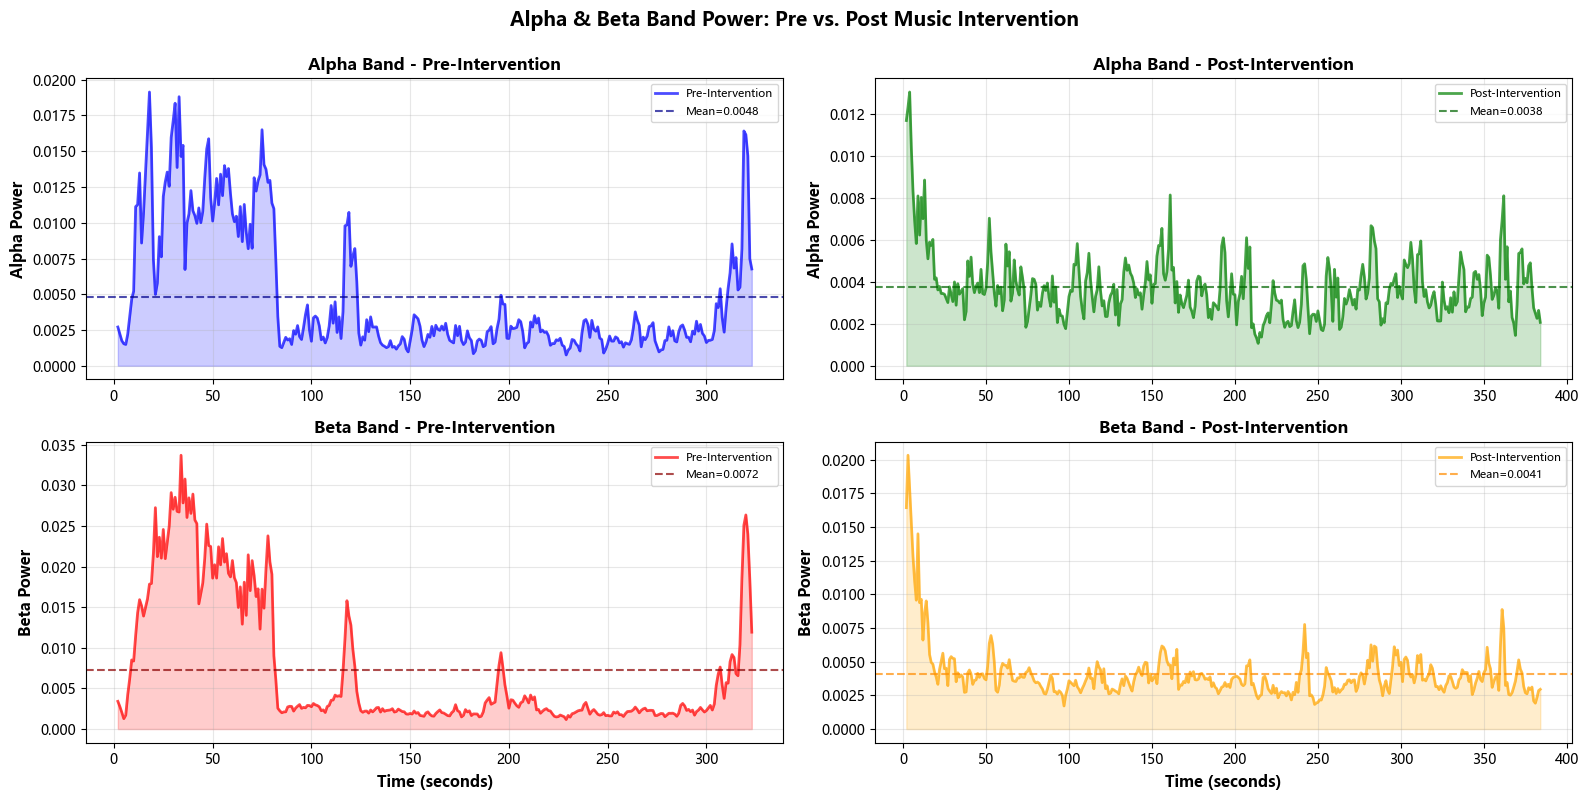

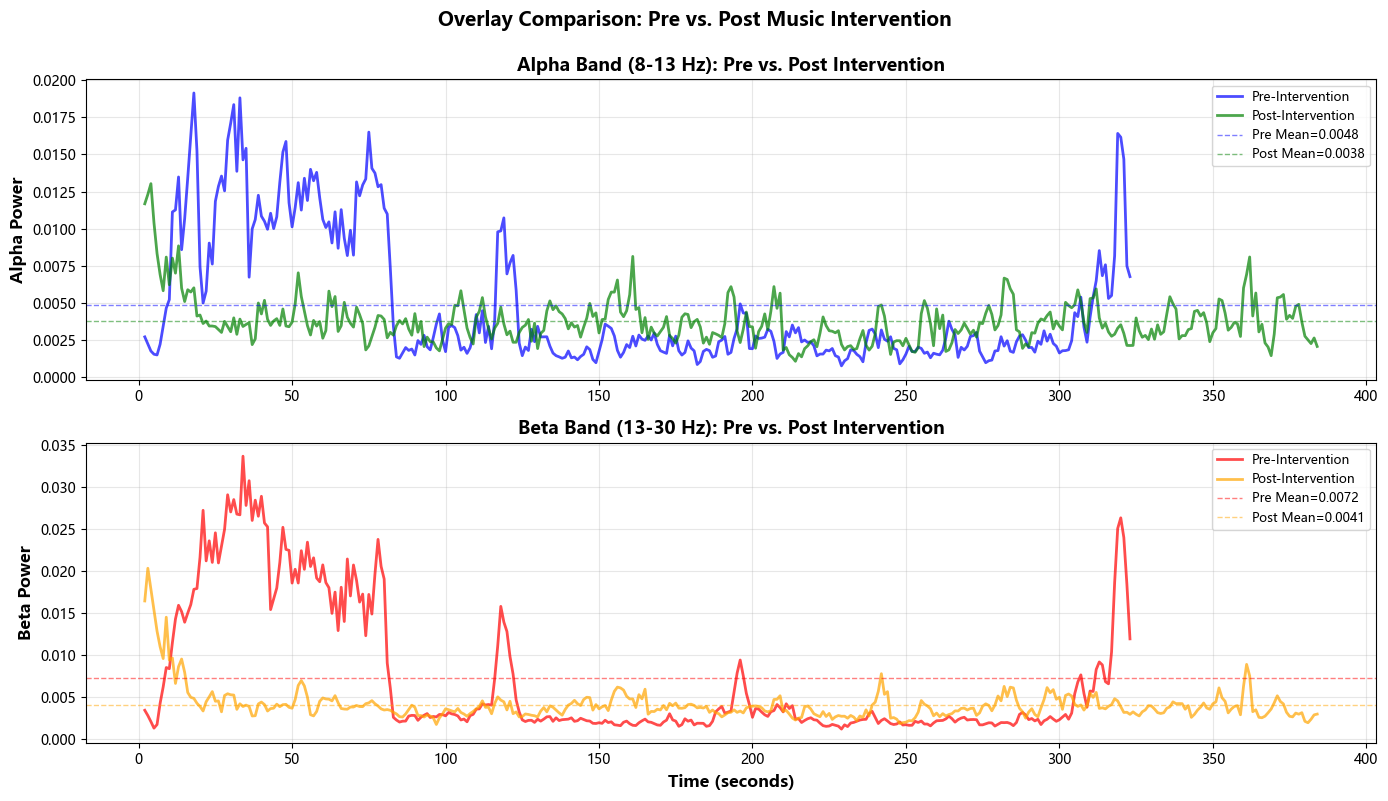

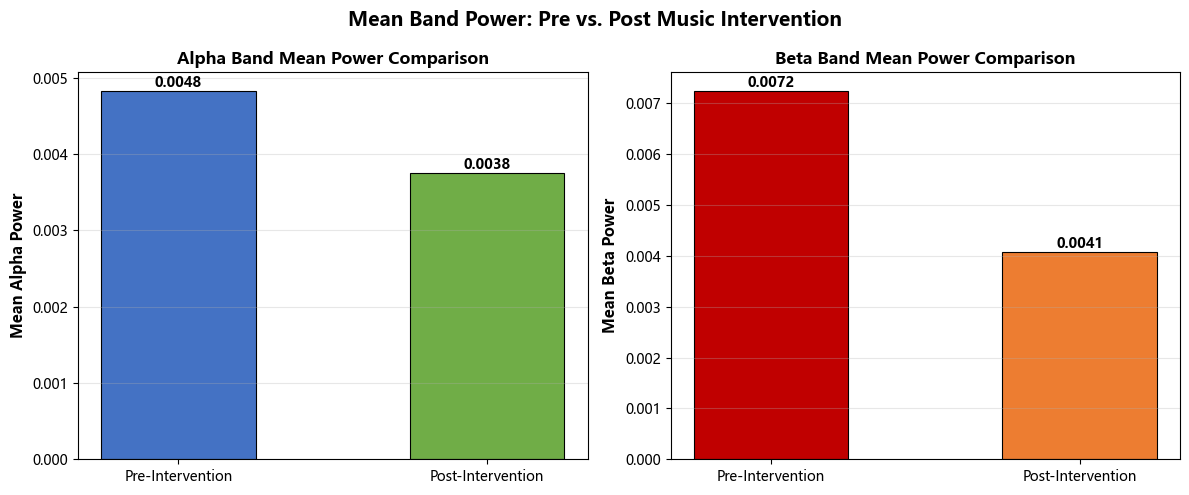


Statistical Comparison Results:

Alpha Band (8-13 Hz):
  Pre-Intervention Mean:   0.004831
  Post-Intervention Mean:  0.003754
  Change: -22.29% (DECREASED)

Beta Band (13-30 Hz):
  Pre-Intervention Mean:   0.007245
  Post-Intervention Mean:  0.004071
  Change: -43.81% (DECREASED)

Alpha/Beta Ratio:
  Pre-Intervention:  0.6668
  Post-Intervention: 0.9221
  Change: +38.28%
Conclusion:
  >> Beta DECREASED 43.8%
  >> Stress reduction observed.



In [29]:
# ============================================================
# 音乐干预前后对比分析
# ============================================================
# 将干预前(Alert)和干预后(Relaxed)的数据进行全面对比
# 会自动生成三张图表, 直接在单元格输出中显示:
#   1. 2x2分离对比图
#   2. 叠加对比图
#   3. 均值柱状图

fig_compare, fig_overlay, fig_bar = compare_before_after(
    file_before=FILE_BEFORE,        # 干预前数据文件
    file_after=FILE_AFTER,          # 干预后数据文件
    sampling_rate=SAMPLING_RATE,    # 采样率
    window_size=WINDOW_SIZE,        # 滑动窗口大小
    overlap=OVERLAP,                # 窗口重叠比例
    channels=CHANNELS               # 分析通道
)

## 9. 结果解读

### Alpha波和Beta波变化的含义

| 变化模式 | 含义 | 音乐干预效果 |
|---------|------|-------------|
| Alpha增强 + Beta降低 | 放松程度增加,警觉/紧张程度降低 | 干预效果显著 |
| Alpha增强 | 出现放松趋势 | 有一定效果 |
| Beta降低 | 压力/紧张程度减轻 | 有一定效果 |
| 变化不明显 | 未出现显著变化 | 可能需要延长干预时间 |

### 关于Alpha/Beta比率
- **Alpha/Beta比率增大**: 表示放松程度相对增加,是音乐干预效果的综合指标
- 该比率可以作为评估音乐干预效果的量化指标

### 注意事项
- 本分析基于频段能量的统计特征,结果受数据质量和采集条件影响
- 建议结合多次实验数据进行综合评估
- 不同个体对音乐干预的响应可能存在差异